In [ ]:
# Statistical Benchmarking and Robustness Analysis of ML Classifiers

#This notebook implements a comparative study of multiple machine learning algorithms across benchmark datasets, including robustness evaluation under label noise conditions.

In [ ]:
#Dataset loading
#Loading dataset 1: Breast Cancer dataset
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Shape of dataset:", X.shape)
print("\nFirst 5 rows:")
display(X.head())

print("\nTarget distribution:")
print(y.value_counts())

Shape of dataset: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target distribution:
1    357
0    212
Name: count, dtype: int64


In [ ]:
#Models used in breast cancer dataset

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9649122807017544

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
#Cross validation benchmarking
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X, y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Cross-validation scores: [0.96491228 0.92105263 0.96491228 0.94736842 0.97345133]
Mean accuracy: 0.9543393882937432
Standard deviation: 0.018683901532046732


In [ ]:
#Results
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=3000)
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name} mean accuracy: {np.mean(scores):.4f}")
    print(f"{name} std deviation: {np.std(scores):.4f}\n")

Logistic Regression mean accuracy: 0.9543
Logistic Regression std deviation: 0.0187

SVM mean accuracy: 0.9139
SVM std deviation: 0.0244

Random Forest mean accuracy: 0.9491
Random Forest std deviation: 0.0170

KNN mean accuracy: 0.9350
KNN std deviation: 0.0196

MLP mean accuracy: 0.9263
MLP std deviation: 0.0402



In [ ]:
from scipy.stats import ttest_rel


In [ ]:
#Statistical testing

model_names = list(results.keys())

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):

        model1 = model_names[i]
        model2 = model_names[j]

        scores1 = results[model1]
        scores2 = results[model2]

        t_stat, p_value = ttest_rel(scores1, scores2)

        print(f"{model1} vs {model2}")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.4f}")

        if p_value < 0.05:
            print("Result: Significant difference")
        else:
            print("Result: No significant difference")

        print("-" * 50)

Logistic Regression vs SVM
T-statistic: 3.8060
P-value: 0.0190
Result: Significant difference
--------------------------------------------------
Logistic Regression vs Random Forest
T-statistic: 2.4494
P-value: 0.0705
Result: No significant difference
--------------------------------------------------
Logistic Regression vs KNN
T-statistic: 2.4047
P-value: 0.0740
Result: No significant difference
--------------------------------------------------
Logistic Regression vs MLP
T-statistic: 1.3990
P-value: 0.2344
Result: No significant difference
--------------------------------------------------
SVM vs Random Forest
T-statistic: -3.3827
P-value: 0.0277
Result: Significant difference
--------------------------------------------------
SVM vs KNN
T-statistic: -2.5870
P-value: 0.0609
Result: No significant difference
--------------------------------------------------
SVM vs MLP
T-statistic: -0.9339
P-value: 0.4032
Result: No significant difference
----------------------------------------------

In [ ]:
#Results summary

import pandas as pd
import numpy as np

summary = []

for model, scores in results.items():
    summary.append({
        "Model": model,
        "Mean Accuracy": np.mean(scores),
        "Std Deviation": np.std(scores)
    })

results_df = pd.DataFrame(summary)

print(results_df)

                 Model  Mean Accuracy  Std Deviation
0  Logistic Regression       0.954339       0.018684
1                  SVM       0.913895       0.024397
2        Random Forest       0.949061       0.016952
3                  KNN       0.935010       0.019610
4                  MLP       0.926254       0.040177


/tmp/ipykernel_823/4075866034.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys())


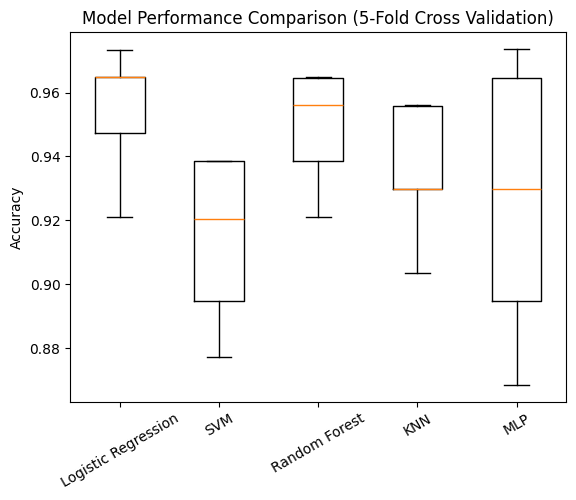

In [ ]:
#Boxplot depicting model performance comparison for breast cancer dataset

import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(results.values(), labels=results.keys())

plt.title("Model Performance Comparison (5-Fold Cross Validation)")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

In [ ]:
#Loading dataset 2: Wine dataset

from sklearn.datasets import load_wine
import pandas as pd

data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)
print(y.value_counts())

print("\nFirst 5 rows:")
display(X.head())



Dataset shape: (178, 13)
1    71
0    59
2    48
Name: count, dtype: int64

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
#Models used

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=3000)
}

results = {}

for name, model in models.items():

    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    results[name] = scores

    print(f"{name} mean accuracy: {np.mean(scores):.4f}")
    print(f"{name} std deviation: {np.std(scores):.4f}")
    print()

Logistic Regression mean accuracy: 0.9663
Logistic Regression std deviation: 0.0211

SVM mean accuracy: 0.6744
SVM std deviation: 0.0398

Random Forest mean accuracy: 0.9830
Random Forest std deviation: 0.0228

KNN mean accuracy: 0.6802
KNN std deviation: 0.0427

MLP mean accuracy: 0.8332
MLP std deviation: 0.1711



In [ ]:
#Results summary

summary = []

for model, scores in results.items():

    summary.append({
        "Model": model,
        "Mean Accuracy": np.mean(scores),
        "Std Deviation": np.std(scores)
    })

results_df = pd.DataFrame(summary)

display(results_df)

,Model,Mean Accuracy,Std Deviation
0,Logistic Regression,0.966349,0.021133
1,SVM,0.674444,0.039769
2,Random Forest,0.983016,0.022780
3,KNN,0.680159,0.042698
4,MLP,0.833175,0.171105


/tmp/ipykernel_823/716734186.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys())


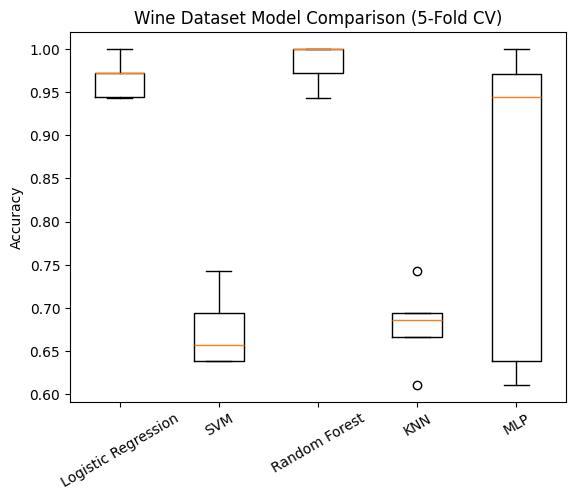

In [ ]:
#Boxplot depicting model performance comparison for Wine dataset

import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(results.values(), labels=results.keys())

plt.title("Wine Dataset Model Comparison (5-Fold CV)")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

In [ ]:
#Loading dataset 3: Digits dataset

from sklearn.datasets import load_digits
import pandas as pd

data = load_digits()

X = pd.DataFrame(data.data)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Dataset shape: (1797, 64)
Target distribution:
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64


In [ ]:
#Models used

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    results[name] = scores

    print(name)
    print("Mean:", scores.mean())
    print("Std:", scores.std())
    print()

Logistic Regression
Mean: 0.9671711544413494
Std: 0.003656806817100471

SVM
Mean: 0.9877561126586197
Std: 0.00417024860785835

Random Forest
Mean: 0.9771819870009286
Std: 0.008872024337853713

KNN
Mean: 0.9871928195605078
Std: 0.007997236518334092

MLP
Mean: 0.9771835345094398
Std: 0.0064391221082875354



/tmp/ipykernel_823/3194209518.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys())


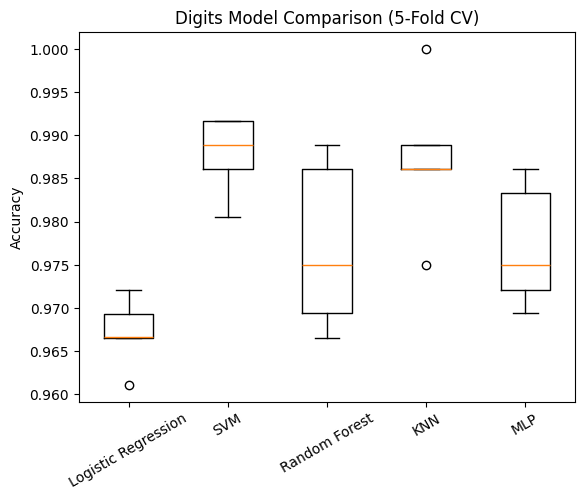

In [ ]:
#Boxplot depicting model performance comparison for digits dataset

import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(results.values(), labels=results.keys())

plt.title("Digits Model Comparison (5-Fold CV)")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

In [ ]:
pip install xgboost

In [ ]:
#Robustness analysis(Label noise)

import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def add_label_noise(y, noise_level=0.2):

    y_noisy = y.copy()
    n_samples = len(y)

    n_noisy = int(noise_level * n_samples)

    noisy_indices = np.random.choice(n_samples, n_noisy, replace=False)

    unique_labels = np.unique(y)

    for i in noisy_indices:
        y_noisy[i] = np.random.choice(unique_labels)

    return y_noisy


y_noisy = add_label_noise(y, noise_level=0.2)

models = {
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

for name, model in models.items():

    scores = cross_val_score(model, X, y_noisy, cv=5, scoring="accuracy")

    print(name)
    print("Mean Accuracy:", scores.mean())
    print("Std:", scores.std())
    print("----------------------")

SVM
Mean Accuracy: 0.789650263076447
Std: 0.03185916534657615
----------------------
Random Forest
Mean Accuracy: 0.7757505416279789
Std: 0.033423971406772064
----------------------


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:29:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:29:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:29:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:29:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost
Mean Accuracy: 0.7328969359331476
Std: 0.04110471635007055
----------------------
